# FL vs SFL — Non-IID One-Label-per-Client, 50 Rounds

This notebook compares **Federated Learning (FL)** and **Split Federated Learning (SFL / Design 1)** on MNIST under an extreme non-IID setting.

**Non-IID setup:** each client receives data from only one label. With MNIST, this notebook uses **10 clients** so that labels 0–9 are all represented.

After every global aggregation round, the notebook evaluates the global model on the full MNIST test set and stores one accuracy value per round for FL and SFL. With 50 rounds, the output table contains 50 accuracy values for FL and 50 accuracy values for SFL.

In [4]:
NOTEBOOK_ID = "05"

import os

# --------------------------------------------------
# Project/output folders
# --------------------------------------------------
# This notebook is normally run from the notebooks/ folder.
# If the current working directory is notebooks/, outputs are saved one level above it:
#     project_root/results/...
#     project_root/weights/...
# If the notebook is run from the project root instead, outputs are saved in that project root.
CURRENT_DIR = os.path.abspath(os.getcwd())
if os.path.basename(CURRENT_DIR).lower() == "notebooks":
    PROJECT_ROOT = os.path.dirname(CURRENT_DIR)
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = os.path.join(PROJECT_ROOT, "data")

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
CSV_DIR = os.path.join(RESULTS_DIR, "csv", NOTEBOOK_ID)
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots", NOTEBOOK_ID)

WEIGHTS_DIR = os.path.join(PROJECT_ROOT, "weights", NOTEBOOK_ID)
FL_WEIGHTS_DIR = os.path.join(WEIGHTS_DIR, "fl")
SFL_WEIGHTS_DIR = os.path.join(WEIGHTS_DIR, "sfl")

for folder in [DATA_DIR, CSV_DIR, PLOTS_DIR, FL_WEIGHTS_DIR, SFL_WEIGHTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("CURRENT_DIR:", CURRENT_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CSV_DIR:", CSV_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("FL_WEIGHTS_DIR:", FL_WEIGHTS_DIR)
print("SFL_WEIGHTS_DIR:", SFL_WEIGHTS_DIR)


CURRENT_DIR: /home/raed/Documents/Masters_project_SFL_servers/notebooks
PROJECT_ROOT: /home/raed/Documents/Masters_project_SFL_servers
DATA_DIR: /home/raed/Documents/Masters_project_SFL_servers/data
CSV_DIR: /home/raed/Documents/Masters_project_SFL_servers/results/csv/05
PLOTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05
FL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05/fl
SFL_WEIGHTS_DIR: /home/raed/Documents/Masters_project_SFL_servers/weights/05/sfl


## Updated model used in this version

This notebook now uses a smaller split-compatible `TwoNN` style model:

```text
Full FL model: 784 -> 256 -> 10
SFL client:    784 -> 256
SFL server:    256 -> 10
```

This is still a valid SFL architecture because the split happens after the hidden layer. The client produces the cut-layer activation of size 256, and the server completes the final classification layer.

The reason for simplifying the model is that the previous 5-layer network was too unstable for the extreme one-label-per-client non-IID case. The smaller model should reduce client drift and should make the FL/SFL equivalence check cleaner.


## Learning-rate update

This version uses the smaller split-compatible `TwoNN` style architecture:

```text
Full model:   784 -> 256 -> 10
SFL client:   784 -> 256
SFL server:   256 -> 10
```

For this simpler architecture, the notebook uses a fixed learning rate:

```python
INITIAL_LR = 0.01
LR_DECAY = 1.0
current_lr = INITIAL_LR * LR_DECAY ** (round_id - 1)
```

There is still no gradient clipping, no momentum, no BatchNorm, and no Adam. This keeps the FL/SFL equivalence check cleaner.


## Diagnostic note: why the one-label non-IID accuracy may not improve

This notebook uses the most extreme label-skew setting: **10 clients and each client receives only one MNIST class**.

That means:

- client 0 only trains on digit 0
- client 1 only trains on digit 1
- ...
- client 9 only trains on digit 9

Although all labels exist globally, each local optimisation step is based on only one class. This can cause **client drift**: each client update strongly pushes the model toward its own class. When FedAvg averages these highly biased updates, the global model may remain close to random guessing, especially with a deeper model, small number of rounds, and conservative learning-rate decay.

Notebook 02 may behave differently because it uses a different FL implementation/model structure and different hyperparameters. In particular, notebook 02 uses a simpler `TwoNN` model and may use different learning rate, local epochs, and experiment settings. Notebook 05 is stricter because it is trying to make FL and SFL mathematically equivalent, so it uses the same starting model, deterministic client loaders, and compares FL and SFL global states using L2 distance.


In [5]:
import os
import copy
import time
import random
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

## 1. Reproducibility and device setup

In [6]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2. Experiment settings and output folders

Run this notebook from the repository root folder: `Masters_project_SFL_servers/`.

In [7]:
# MNIST has 10 labels, so using 10 clients gives one label per client and still covers all classes.
NUM_CLIENTS = 10
ROUNDS = 100
LOCAL_EPOCHS = 1
BATCH_SIZE = 64
TEST_BATCH_SIZE = 256

# Set to an integer such as 1000 for a quick test run.
# Set to None for the full one-label-per-client dataset.
MAX_SAMPLES_PER_CLIENT = None

print("CSV results will be saved to:", CSV_DIR)
print("Plots will be saved to:", PLOTS_DIR)
print("Weights will be saved to:", WEIGHTS_DIR)

# --------------------------------------------------
# Learning rate
# --------------------------------------------------
# Fixed LR for the smaller 784 -> 256 -> 10 architecture.
# This notebook is kept without gradient clipping to preserve FL/SFL equivalence.
INITIAL_LR = 0.01
LR_DECAY = 1.0

def get_round_lr(round_id):
    """
    Return the learning rate for the current communication round.

    Example:
        round 1   -> 0.01
        round 100 -> 0.01 because LR_DECAY = 1.0
    """
    return INITIAL_LR * (LR_DECAY ** (round_id - 1))


CSV results will be saved to: /home/raed/Documents/Masters_project_SFL_servers/results/csv/05
Plots will be saved to: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05
Weights will be saved to: /home/raed/Documents/Masters_project_SFL_servers/weights/05


## 3. Load MNIST dataset

In [8]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 60000
Test samples: 10000


## 4. Create non-IID client datasets

Each client receives samples from only one label.

Example: client 1 gets label 0, client 2 gets label 1, ..., client 10 gets label 9.

In [9]:
def get_targets(dataset):
    if hasattr(dataset, "targets"):
        targets = dataset.targets
        if torch.is_tensor(targets):
            targets = targets.cpu().numpy()
        return np.array(targets)
    return np.array([dataset[i][1] for i in range(len(dataset))])


def create_one_label_client_subsets(dataset, num_clients: int, seed: int, max_samples_per_client=None):
    targets = get_targets(dataset)
    unique_labels = sorted(np.unique(targets).tolist())

    if num_clients > len(unique_labels):
        raise ValueError("num_clients cannot be greater than the number of labels for one-label-per-client setup.")

    selected_labels = unique_labels[:num_clients]
    rng = np.random.default_rng(seed)

    subsets = []
    client_label_map = {}

    for client_id, label in enumerate(selected_labels):
        label_indices = np.where(targets == label)[0]
        rng.shuffle(label_indices)

        if max_samples_per_client is not None:
            label_indices = label_indices[:max_samples_per_client]

        subsets.append(Subset(dataset, label_indices.tolist()))
        client_label_map[client_id] = label

    return subsets, client_label_map


client_subsets, client_label_map = create_one_label_client_subsets(
    train_dataset,
    num_clients=NUM_CLIENTS,
    seed=SEED,
    max_samples_per_client=MAX_SAMPLES_PER_CLIENT,
)

for client_id, subset in enumerate(client_subsets):
    print(f"Client {client_id + 1}: label={client_label_map[client_id]}, samples={len(subset)}")

sample_counts = [len(subset) for subset in client_subsets]
print("Total samples used:", sum(sample_counts))

Client 1: label=0, samples=5923
Client 2: label=1, samples=6742
Client 3: label=2, samples=5958
Client 4: label=3, samples=6131
Client 5: label=4, samples=5842
Client 6: label=5, samples=5421
Client 7: label=6, samples=5918
Client 8: label=7, samples=6265
Client 9: label=8, samples=5851
Client 10: label=9, samples=5949
Total samples used: 60000


## 5. Data loaders

FL and SFL use the same deterministic batch order for each client and round.

In [10]:
def make_client_loader(client_id: int, round_id: int, method_tag: str):
    # Same seed formula for FL and SFL ensures identical batch order.
    loader_seed = SEED + round_id * 1000 + client_id
    generator = torch.Generator().manual_seed(loader_seed)

    return DataLoader(
        client_subsets[client_id],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )


test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
)

## 6. Models

In [11]:
from collections import OrderedDict

class FullModel(nn.Module):
    """
    Full FL model for notebook 05.

    Smaller split-compatible TwoNN-style architecture:
        Flatten
        fc1: 784 -> 256
        ReLU
        fc2: 256 -> 10

    SFL split:
        Client side: fc1 + ReLU
        Server side: fc2
    """

    def __init__(self, input_dim=28 * 28, hidden_dim=256, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        return self.fc2(x)


class ClientModel(nn.Module):
    """
    SFL client-side model.

    Contains:
        Flatten -> fc1 -> ReLU

    The cut-layer activation has shape [batch_size, 256].
    """

    def __init__(self, input_dim=28 * 28, hidden_dim=256):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        return self.relu1(self.fc1(x))


class ServerModel(nn.Module):
    """
    SFL server-side model.

    Contains:
        fc2: 256 -> 10
    """

    def __init__(self, hidden_dim=256, num_classes=10):
        super().__init__()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        return self.fc2(x)


def full_to_client_state(full_state):
    """
    Extract client-side weights from the full model.
    Client side contains fc1 only.
    """
    return OrderedDict({
        "fc1.weight": full_state["fc1.weight"].clone(),
        "fc1.bias": full_state["fc1.bias"].clone(),
    })


def full_to_server_state(full_state):
    """
    Extract server-side weights from the full model.
    Server side contains fc2 only.
    """
    return OrderedDict({
        "fc2.weight": full_state["fc2.weight"].clone(),
        "fc2.bias": full_state["fc2.bias"].clone(),
    })


def split_to_full_state(client_state, server_state):
    """
    Reconstruct a full model state_dict from SFL client and server states.
    This is used to evaluate and compare SFL against FL.
    """
    return OrderedDict({
        "fc1.weight": client_state["fc1.weight"].clone(),
        "fc1.bias": client_state["fc1.bias"].clone(),
        "fc2.weight": server_state["fc2.weight"].clone(),
        "fc2.bias": server_state["fc2.bias"].clone(),
    })


## 7. State dictionary helpers

In [12]:
def get_state_dict(model: nn.Module):
    return OrderedDict((k, v.detach().cpu().clone()) for k, v in model.state_dict().items())


def load_state_dict_to_model(model: nn.Module, state_dict):
    model.load_state_dict(state_dict, strict=True)


def full_to_client_state(full_state):
    return OrderedDict({
        "fc1.weight": full_state["fc1.weight"].clone(),
        "fc1.bias": full_state["fc1.bias"].clone(),
    })


def full_to_server_state(full_state):
    return OrderedDict({
        "fc2.weight": full_state["fc2.weight"].clone(),
        "fc2.bias": full_state["fc2.bias"].clone(),
    })


def split_to_full_state(client_state, server_state):
    return OrderedDict({
        "fc1.weight": client_state["fc1.weight"].clone(),
        "fc1.bias": client_state["fc1.bias"].clone(),
        "fc2.weight": server_state["fc2.weight"].clone(),
        "fc2.bias": server_state["fc2.bias"].clone(),
    })


def fedavg_state_dicts(state_dicts, sample_counts):
    total_samples = sum(sample_counts)
    avg_state = OrderedDict()

    for key in state_dicts[0].keys():
        avg_tensor = torch.zeros_like(state_dicts[0][key], dtype=torch.float32)
        for state, n in zip(state_dicts, sample_counts):
            avg_tensor += state[key].float() * (n / total_samples)
        avg_state[key] = avg_tensor

    return avg_state


def l2_distance_state_dicts(state_a, state_b):
    total_sq = 0.0
    for key in state_a.keys():
        diff = state_a[key].float() - state_b[key].float()
        total_sq += torch.sum(diff ** 2).item()
    return total_sq ** 0.5


## 8. Evaluation function

In [13]:
@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

## 9. FL client training

In [14]:
def train_fl_client(start_global_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    model = FullModel().to(device)
    load_state_dict_to_model(model, start_global_state)

    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return get_state_dict(model)

## 10. SFL Design 1 client training

Each client trains a client-side copy and an independent server-side copy for that round. Then both parts are aggregated with FedAvg.

In [15]:
def train_sfl_client_design1(start_client_state, start_server_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    client_model = ClientModel().to(device)
    server_model = ServerModel().to(device)

    load_state_dict_to_model(client_model, start_client_state)
    load_state_dict_to_model(server_model, start_server_state)

    client_model.train()
    server_model.train()

    criterion = nn.CrossEntropyLoss()
    client_optimizer = optim.SGD(client_model.parameters(), lr=lr)
    server_optimizer = optim.SGD(server_model.parameters(), lr=lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            client_optimizer.zero_grad()
            server_optimizer.zero_grad()

            smashed_data = client_model(x)
            smashed_data_detached = smashed_data.detach().requires_grad_(True)

            logits = server_model(smashed_data_detached)
            loss = criterion(logits, y)
            loss.backward()

            grad_to_client = smashed_data_detached.grad.clone()
            server_optimizer.step()

            smashed_data.backward(grad_to_client)
            client_optimizer.step()

    return get_state_dict(client_model), get_state_dict(server_model)

## 11. Initialise FL and SFL from identical weights

In [16]:
set_seed(SEED)
initial_full_model = FullModel()
initial_full_state = get_state_dict(initial_full_model)

fl_global_state = copy.deepcopy(initial_full_state)
sfl_global_client_state = full_to_client_state(initial_full_state)
sfl_global_server_state = full_to_server_state(initial_full_state)

print("Initial FL and SFL states prepared from the same full model.")

Initial FL and SFL states prepared from the same full model.


## 12. Run 100 rounds and evaluate global accuracy after every round


In [17]:
results = []

for round_id in range(1, ROUNDS + 1):

    # Use a reduced learning rate that decays each communication round
    current_lr = get_round_lr(round_id)
    print(f"Learning rate this round: {current_lr:.6f}")
    print(f"\n========== Round {round_id}/{ROUNDS} ==========")
    round_start_time = time.perf_counter()

    # -------------------------
    # FL local training
    # -------------------------
    fl_start_time = time.perf_counter()
    fl_client_states = []

    for client_id in range(NUM_CLIENTS):
        loader = make_client_loader(client_id, round_id, method_tag="fl")
        trained_state = train_fl_client(
            start_global_state=fl_global_state,
            train_loader=loader,
            local_epochs=LOCAL_EPOCHS,
            lr=current_lr,
            device=device,
        )
        fl_client_states.append(trained_state)

    fl_global_state = fedavg_state_dicts(fl_client_states, sample_counts)
    fl_time = time.perf_counter() - fl_start_time

    # Save only global model every round to avoid too many files.
    torch.save(fl_global_state, os.path.join(FL_WEIGHTS_DIR, f"fl_round_{round_id:03d}_global.pth"))

    # -------------------------
    # SFL Design 1 local training
    # -------------------------
    sfl_start_time = time.perf_counter()
    sfl_client_side_states = []
    sfl_server_side_states = []

    for client_id in range(NUM_CLIENTS):
        loader = make_client_loader(client_id, round_id, method_tag="sfl")
        trained_client_state, trained_server_state = train_sfl_client_design1(
            start_client_state=sfl_global_client_state,
            start_server_state=sfl_global_server_state,
            train_loader=loader,
            local_epochs=LOCAL_EPOCHS,
            lr=current_lr,
            device=device,
        )
        sfl_client_side_states.append(trained_client_state)
        sfl_server_side_states.append(trained_server_state)

    sfl_global_client_state = fedavg_state_dicts(sfl_client_side_states, sample_counts)
    sfl_global_server_state = fedavg_state_dicts(sfl_server_side_states, sample_counts)
    sfl_global_full_state = split_to_full_state(sfl_global_client_state, sfl_global_server_state)
    sfl_time = time.perf_counter() - sfl_start_time

    torch.save(sfl_global_client_state, os.path.join(SFL_WEIGHTS_DIR, f"sfl_round_{round_id:03d}_global_client_side.pth"))
    torch.save(sfl_global_server_state, os.path.join(SFL_WEIGHTS_DIR, f"sfl_round_{round_id:03d}_global_server_side.pth"))
    torch.save(sfl_global_full_state, os.path.join(SFL_WEIGHTS_DIR, f"sfl_round_{round_id:03d}_global_full_reconstructed.pth"))

    # -------------------------
    # Evaluate global models after aggregation
    # -------------------------
    eval_start_time = time.perf_counter()

    fl_eval_model = FullModel().to(device)
    load_state_dict_to_model(fl_eval_model, fl_global_state)
    fl_test_loss, fl_test_acc = evaluate_model(fl_eval_model, test_loader, device)

    sfl_eval_model = FullModel().to(device)
    load_state_dict_to_model(sfl_eval_model, sfl_global_full_state)
    sfl_test_loss, sfl_test_acc = evaluate_model(sfl_eval_model, test_loader, device)

    eval_time = time.perf_counter() - eval_start_time
    total_round_time = time.perf_counter() - round_start_time

    global_l2 = l2_distance_state_dicts(fl_global_state, sfl_global_full_state)

    results.append({
        "round": round_id,
        "fl_test_loss": fl_test_loss,
        "fl_test_accuracy": fl_test_acc,
        "sfl_test_loss": sfl_test_loss,
        "sfl_test_accuracy": sfl_test_acc,
        "fl_minus_sfl_accuracy": fl_test_acc - sfl_test_acc,
        "global_l2_distance_fl_vs_sfl": global_l2,
        "fl_time_sec": fl_time,
        "sfl_time_sec": sfl_time,
        "evaluation_time_sec": eval_time,
        "total_round_time_sec": total_round_time,
    })

    print(
        f"Round {round_id:03d} | "
        f"FL acc={fl_test_acc:.4f}, SFL acc={sfl_test_acc:.4f}, "
        f"L2={global_l2:.6f}, "
        f"FL time={fl_time:.1f}s, SFL time={sfl_time:.1f}s"
    )

results_df = pd.DataFrame(results)
display(results_df)

# --------------------------------------------------
# Decaying learning rate
# --------------------------------------------------
# A lower initial LR helps reduce client drift in the extreme one-label/client case.
INITIAL_LR = 0.0015

# Decay is slow so learning does not disappear too quickly across 50 rounds.
LR_DECAY = 0.997

def get_round_lr(round_id):
    """
    Return the learning rate for the current communication round.

    Example:
        round 1  -> 0.0015
        round 50 -> 0.0015 * 0.997^49
    """
    return INITIAL_LR * (LR_DECAY ** (round_id - 1))


Learning rate this round: 0.010000

========== Round 1/100 ==========
Round 001 | FL acc=0.2801, SFL acc=0.2801, L2=0.000000, FL time=2.7s, SFL time=2.6s
Learning rate this round: 0.010000

========== Round 2/100 ==========
Round 002 | FL acc=0.3366, SFL acc=0.3366, L2=0.000000, FL time=2.5s, SFL time=2.7s
Learning rate this round: 0.010000

========== Round 3/100 ==========
Round 003 | FL acc=0.3951, SFL acc=0.3951, L2=0.000000, FL time=2.7s, SFL time=2.8s
Learning rate this round: 0.010000

========== Round 4/100 ==========
Round 004 | FL acc=0.4470, SFL acc=0.4470, L2=0.000000, FL time=2.7s, SFL time=2.8s
Learning rate this round: 0.010000

========== Round 5/100 ==========
Round 005 | FL acc=0.4850, SFL acc=0.4850, L2=0.000000, FL time=2.7s, SFL time=2.7s
Learning rate this round: 0.010000

========== Round 6/100 ==========
Round 006 | FL acc=0.5184, SFL acc=0.5184, L2=0.000000, FL time=2.7s, SFL time=2.6s
Learning rate this round: 0.010000

========== Round 7/100 ==========
Round 

,round,fl_test_loss,fl_test_accuracy,sfl_test_loss,sfl_test_accuracy,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl,fl_time_sec,sfl_time_sec,evaluation_time_sec,total_round_time_sec
0,1,2.238074,0.2801,2.238074,0.2801,0.0,0.0,2.747742,2.618164,0.614992,5.987723
1,2,2.172715,0.3366,2.172715,0.3366,0.0,0.0,2.456585,2.652183,0.581137,5.696518
2,3,2.115539,0.3951,2.115539,0.3951,0.0,0.0,2.683701,2.847965,0.594139,6.132504
3,4,2.065000,0.4470,2.065000,0.4470,0.0,0.0,2.650459,2.820007,0.588240,6.066111
4,5,2.019404,0.4850,2.019404,0.4850,0.0,0.0,2.680621,2.711114,0.577690,5.975861
...,...,...,...,...,...,...,...,...,...,...,...
95,96,0.941596,0.7755,0.941596,0.7755,0.0,0.0,2.530204,2.594385,0.569127,5.695993
96,97,0.938111,0.7769,0.938111,0.7769,0.0,0.0,2.302683,2.527187,0.562154,5.398455
97,98,0.933351,0.7782,0.933351,0.7782,0.0,0.0,2.407430,2.583267,0.573037,5.566062
98,99,0.929679,0.7780,0.929679,0.7780,0.0,0.0,2.456886,2.458721,0.572314,5.490217


## 13. Save CSV results

In [18]:
results_csv_path = os.path.join(CSV_DIR, f"fl_vs_sfl_noniid_one_label_{ROUNDS}_rounds.csv")
results_df.to_csv(results_csv_path, index=False)
print("Saved results CSV to:", results_csv_path)


Saved results CSV to: /home/raed/Documents/Masters_project_SFL_servers/results/csv/05/fl_vs_sfl_noniid_one_label_100_rounds.csv


## 14. Plot FL vs SFL accuracy

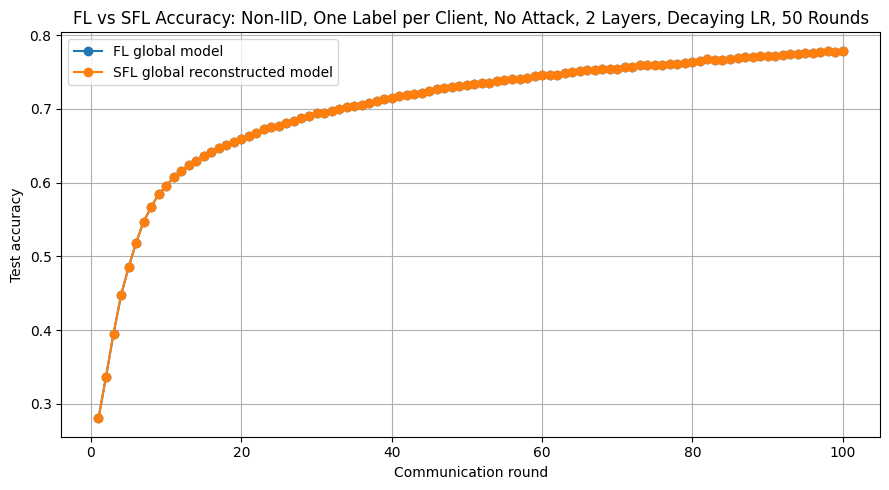

Saved accuracy plot to: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05/fl_vs_sfl_noniid_one_label_accuracy_100_rounds.png


In [19]:
accuracy_plot_path = os.path.join(PLOTS_DIR, f"fl_vs_sfl_noniid_one_label_accuracy_{ROUNDS}_rounds.png")

plt.figure(figsize=(9, 5))
plt.plot(results_df["round"], results_df["fl_test_accuracy"], marker="o", label="FL global model")
plt.plot(results_df["round"], results_df["sfl_test_accuracy"], marker="o", label="SFL global reconstructed model")
plt.xlabel("Communication round")
plt.ylabel("Test accuracy")
plt.title("FL vs SFL Accuracy: Non-IID, One Label per Client, No Attack, 2 Layers, Decaying LR, 50 Rounds")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(accuracy_plot_path, dpi=200)
plt.show()

print("Saved accuracy plot to:", accuracy_plot_path)


## 15. Plot FL vs SFL loss

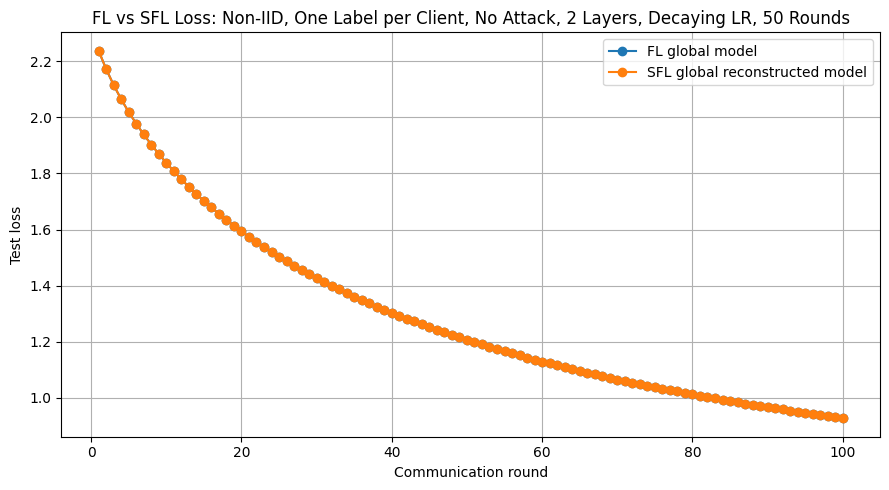

Saved loss plot to: /home/raed/Documents/Masters_project_SFL_servers/results/plots/05/fl_vs_sfl_noniid_one_label_loss_100_rounds.png


In [22]:
loss_plot_path = os.path.join(PLOTS_DIR, f"fl_vs_sfl_noniid_one_label_loss_{ROUNDS}_rounds.png")

plt.figure(figsize=(9, 5))
plt.plot(results_df["round"], results_df["fl_test_loss"], marker="o", label="FL global model")
plt.plot(results_df["round"], results_df["sfl_test_loss"], marker="o", label="SFL global reconstructed model")
plt.xlabel("Communication round")
plt.ylabel("Test loss")
plt.title("FL vs SFL Loss: Non-IID, One Label per Client, No Attack, 2 Layers, Decaying LR, 50 Rounds")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(loss_plot_path, dpi=200)
plt.show()

print("Saved loss plot to:", loss_plot_path)


## 16. Short report text for README / thesis notes

In [23]:
summary_text = f"""
Experiment: FL vs SFL under extreme non-IID data distribution.

Architecture: 784 -> 256 -> 10, split as client 784 -> 256 and server 256 -> 10.
Dataset: MNIST.
Clients: {NUM_CLIENTS}.
Non-IID setting: each client receives data from only one label/class.
Communication rounds: {ROUNDS}.
Local epochs per client per round: {LOCAL_EPOCHS}.

The global model was evaluated after every aggregation round on the full MNIST test set.
The final FL accuracy was {results_df['fl_test_accuracy'].iloc[-1]:.4f}.
The final SFL accuracy was {results_df['sfl_test_accuracy'].iloc[-1]:.4f}.

The saved CSV file contains one row per communication round, giving {ROUNDS} accuracy values for FL and {ROUNDS} accuracy values for SFL.
"""

summary_path = os.path.join(CSV_DIR, f"fl_vs_sfl_noniid_one_label_summary_{ROUNDS}_rounds.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print("Saved summary text to:", summary_path)



Experiment: FL vs SFL under extreme non-IID data distribution.

Architecture: 784 -> 256 -> 10, split as client 784 -> 256 and server 256 -> 10.
Dataset: MNIST.
Clients: 10.
Non-IID setting: each client receives data from only one label/class.
Communication rounds: 100.
Local epochs per client per round: 1.

The global model was evaluated after every aggregation round on the full MNIST test set.
The final FL accuracy was 0.7791.
The final SFL accuracy was 0.7791.

The saved CSV file contains one row per communication round, giving 100 accuracy values for FL and 100 accuracy values for SFL.

Saved summary text to: /home/raed/Documents/Masters_project_SFL_servers/results/csv/05/fl_vs_sfl_noniid_one_label_summary_100_rounds.txt


## Comparison with the earlier 5-layer notebook

This version replaces the deeper 5-layer fully connected network with a smaller split-compatible model:

```text
Full FL model: 784 -> 256 -> 10
SFL client:    784 -> 256
SFL server:    256 -> 10
```

Why this should help:

1. **Less client drift**  
   In the one-label-per-client case, each client update is strongly biased toward one class. A smaller model usually drifts less than a deeper 5-layer MLP.

2. **Cleaner FL/SFL equivalence**  
   There are fewer layers and fewer parameters, so the reconstructed SFL global model should remain closer to the FL global model.

3. **Better accuracy stability**  
   The previous loss curve was decreasing, but accuracy collapsed. That suggests the model was learning something but not maintaining a stable multi-class decision boundary. A smaller model is less likely to over-specialise to each client class.

4. **Still valid for split learning**  
   Even though this is a 2-layer model, it is still a valid SFL design because the split happens after the hidden layer.

Recommended next checks:

- Watch whether the L2 distance stays close to zero.
- Compare the accuracy curve against the 5-layer version.
- If accuracy is still too low, test `INITIAL_LR = 0.005`, `0.01`, and `0.02` with `LR_DECAY = 1.0`.
- After this equivalence check works, repeat with 2, 4, and 6 labels per client.
